# Análisis de Rendimiento de Campañas de Marketing Digital

**Trabajo Final Integrador — Herramientas Básicas para el Análisis de Datos**
**Autora:** Agustina Pérez
**Curso:** UTN.BA — Centro de e-Learning

## Pregunta de análisis
¿Qué plataforma (Meta, TikTok, Google Search, Google Display, Snapchat,
LinkedIn) genera mejor retorno de inversión (ROAS), y cómo varía este
resultado según el tipo de campaña (objetivo)?

## Dataset
Digital Marketing Performance Dataset (Kaggle, sintético) — 30.000 filas,
35 columnas, período 2023-2025.


In [1]:
from google.colab import files
uploaded = files.upload()

Saving digital_marketing_dataset_30k[1].csv to digital_marketing_dataset_30k[1].csv


In [2]:
import pandas as pd

df = pd.read_csv("digital_marketing_dataset_30k[1].csv")
df.head()

,date,year,month,month_name,week,day_of_week,post_hour,season,is_holiday,is_holiday (text),...,ad_id,ad_name,spend,impressions,reach,frequency,clicks,conversions,revenue,video_views
0,08/04/2023,2023,4,Apr,14,Sat,7,Spring,0,No,...,AD8747890,In-Feed_V1,871.17,172632,77865,2.22,1440,0,0.00,54610
1,28/04/2025,2025,4,Apr,18,Mon,12,Spring,0,No,...,AD2884130,Feed_V9,362.55,30111,15083,2.00,283,0,0.00,8086
2,18/12/2024,2024,12,Dec,51,Wed,10,Winter,0,No,...,AD5656772,Display_V7,362.09,111125,56453,1.97,1238,7,671.74,0
3,26/04/2024,2024,4,Apr,17,Fri,20,Spring,0,No,...,AD3443678,Stories_V2,54.45,10844,4736,2.29,83,0,0.00,0
4,19/04/2024,2024,4,Apr,16,Fri,22,Spring,0,No,...,AD8461978,Reels_V8,56.18,6423,3010,2.13,59,0,0.00,1160


In [4]:
# 1. ¿Cuántas filas y columnas tiene?
print("Tamaño del dataset:", df.shape)

# 2. ¿Qué tipo de dato tiene cada columna?
df.info()

# 3. ¿Hay valores nulos (vacíos)?
print("\nValores nulos por columna:")
print(df.isnull().sum())


Tamaño del dataset: (30000, 35)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 35 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   date               30000 non-null  object 
 1   year               30000 non-null  int64  
 2   month              30000 non-null  int64  
 3   month_name         30000 non-null  object 
 4   week               30000 non-null  int64  
 5   day_of_week        30000 non-null  object 
 6   post_hour          30000 non-null  int64  
 7   season             30000 non-null  object 
 8   is_holiday         30000 non-null  int64  
 9   is_holiday (text)  30000 non-null  object 
 10  is_weekend         30000 non-null  int64  
 11  is_weekend (text)  30000 non-null  object 
 12  country            30000 non-null  object 
 13  market_tier        30000 non-null  object 
 14  account            30000 non-null  object 
 15  account_type       30000 non-null  obj

In [6]:
# ¿Hay filas totalmente duplicadas?
print("Filas duplicadas:", df.duplicated().sum())

# ¿Cómo está guardada la fecha?
print("\nTipo de dato de 'date':", df['date'].dtype)
print("Ejemplo de fechas:", df['date'].head(3).tolist())


Filas duplicadas: 0

Tipo de dato de 'date': object
Ejemplo de fechas: ['08/04/2023', '28/04/2025', '18/12/2024']


In [7]:
# Convertimos la columna 'date' de texto a fecha real
# El formato original es día/mes/año (dayfirst=True le avisa a Python ese orden)
df['date'] = pd.to_datetime(df['date'], dayfirst=True)

# Verificamos que funcionó
print("Nuevo tipo de dato:", df['date'].dtype)
print("Ejemplo:", df['date'].head(3).tolist())

Nuevo tipo de dato: datetime64[ns]
Ejemplo: [Timestamp('2023-04-08 00:00:00'), Timestamp('2025-04-28 00:00:00'), Timestamp('2024-12-18 00:00:00')]


In [8]:
# Sacamos las columnas de texto que son redundantes
# (ya tenemos la misma info en formato 0/1, que es más útil para filtrar)
df = df.drop(columns=['is_holiday (text)', 'is_weekend (text)'])

# Confirmamos el nuevo tamaño
print("Nuevo tamaño del dataset:", df.shape)
print("\nColumnas actuales:")
print(df.columns.tolist())


Nuevo tamaño del dataset: (30000, 33)

Columnas actuales:
['date', 'year', 'month', 'month_name', 'week', 'day_of_week', 'post_hour', 'season', 'is_holiday', 'is_weekend', 'country', 'market_tier', 'account', 'account_type', 'platform', 'placement', 'funnel_stage', 'objective', 'theme', 'campaign_id', 'campaign_name', 'ad_group_id', 'ad_group_name', 'ad_id', 'ad_name', 'spend', 'impressions', 'reach', 'frequency', 'clicks', 'conversions', 'revenue', 'video_views']


In [9]:
# Calculamos ROAS = revenue / spend
# Usamos .replace(0, pd.NA) para evitar dividir por cero cuando spend=0
df['roas'] = df['revenue'] / df['spend']

# También calculamos CTR (Click-Through Rate) = clicks / impressions
# Nos dice qué % de la gente que vio el anuncio, hizo clic
df['ctr'] = df['clicks'] / df['impressions']

# Vemos un resumen de estos nuevos KPIs
df[['spend', 'revenue', 'roas', 'clicks', 'impressions', 'ctr']].describe()

,spend,revenue,roas,clicks,impressions,ctr
count,30000.000000,30000.000000,30000.000000,30000.000000,3.000000e+04,30000.000000
mean,421.213635,475.711809,1.076159,853.904667,5.672545e+04,0.018236
std,463.299038,2814.167209,3.882109,1485.987745,8.022802e+04,0.020224
min,18.840000,0.000000,0.000000,3.000000,6.930000e+02,0.001861
25%,86.147500,0.000000,0.000000,109.000000,9.432750e+03,0.007282
50%,229.915000,0.000000,0.000000,311.500000,2.543800e+04,0.009850
75%,609.312500,72.350000,0.489142,961.000000,6.961450e+04,0.014367
max,3759.940000,104733.410000,92.001153,30884.000000,1.015972e+06,0.137598


In [10]:
# Vemos cuánto revenue génera cada tipo de objetivo de campaña
df.groupby('objective')['revenue'].agg(['mean', 'count'])

,mean,count
objective,,
Engagement,0.000000,4420
Leads,877.176753,4490
Reach,0.000000,6032
Sales,1894.889169,5453
Traffic,0.000000,5527
Video Views,0.000000,4078


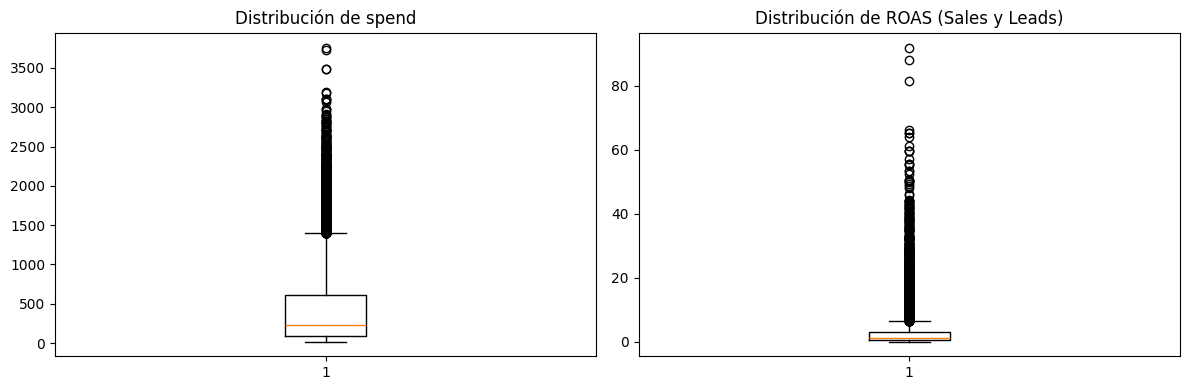

In [11]:
import matplotlib.pyplot as plt

# Miramos la distribución del spend y del ROAS con un boxplot
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].boxplot(df['spend'])
axes[0].set_title('Distribución de spend')

# Para el ROAS, miramos solo Sales y Leads (donde tiene sentido calcularlo)
roas_valido = df[df['objective'].isin(['Sales', 'Leads'])]['roas']
axes[1].boxplot(roas_valido)
axes[1].set_title('Distribución de ROAS (Sales y Leads)')

plt.tight_layout()
plt.show()

In [13]:
# Decisión sobre outliers:
# Se detectaron valores atípicos en 'spend' y 'roas' mediante boxplot.
# Se optó por NO eliminarlos, ya que representan campañas reales de alto
# rendimiento (ej: picos de gasto en fechas estacionales, o campañas virales
# con ROAS excepcional) y no errores de carga. Eliminarlos ocultaría
# información valiosa para el análisis de negocio.

# Guardamos el dataset ya limpio en un nuevo archivo
df.to_csv('digital_marketing_clean.csv', index=False)
print("Dataset limpio guardado. Filas:", df.shape[0], "- Columnas:", df.shape[1])

Dataset limpio guardado. Filas: 30000 - Columnas: 35


/tmp/ipykernel_658/3288035024.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=roas_por_plataforma.values, y=roas_por_plataforma.index, palette='viridis')


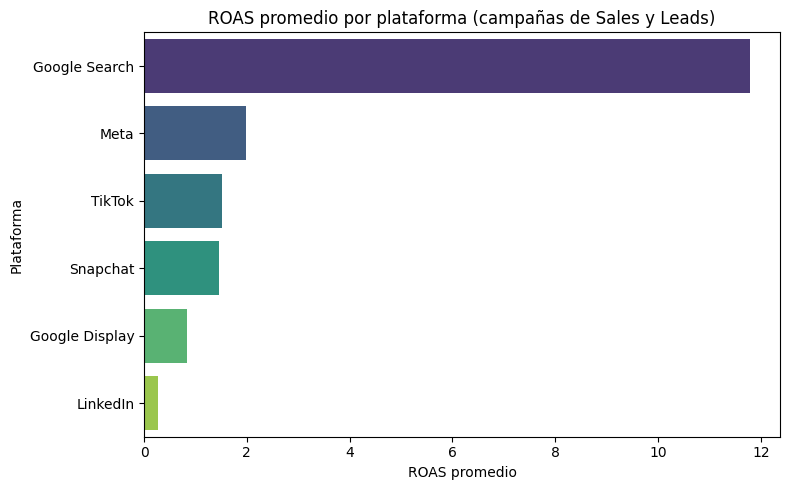

In [14]:
import seaborn as sns

# Filtramos solo campañas que generan revenue real
df_conversion = df[df['objective'].isin(['Sales', 'Leads'])]

# Calculamos el ROAS promedio por plataforma
roas_por_plataforma = df_conversion.groupby('platform')['roas'].mean().sort_values(ascending=False)

# Graficamos
plt.figure(figsize=(8, 5))
sns.barplot(x=roas_por_plataforma.values, y=roas_por_plataforma.index, palette='viridis')
plt.xlabel('ROAS promedio')
plt.ylabel('Plataforma')
plt.title('ROAS promedio por plataforma (campañas de Sales y Leads)')
plt.tight_layout()
plt.show()

**Interpretación:** Google Search presenta el ROAS promedio más alto
(aproximadamente 11x) entre todas las plataformas analizadas, muy por encima
de Meta (aproximadamente 2x), que ocupa el segundo lugar. Esto sugiere que
las campañas de búsqueda, al capturar intención de compra activa, son
significativamente más eficientes en retorno de inversión que las plataformas
de redes sociales para objetivos de conversión (Sales/Leads).


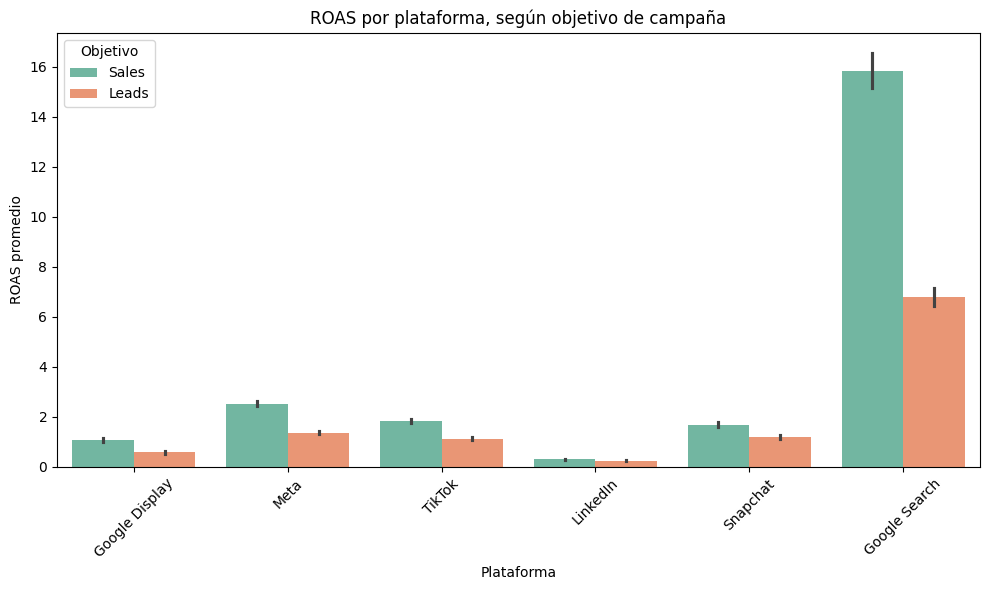

In [15]:
plt.figure(figsize=(10, 6))
sns.barplot(data=df_conversion, x='platform', y='roas', hue='objective', palette='Set2')
plt.xlabel('Plataforma')
plt.ylabel('ROAS promedio')
plt.title('ROAS por plataforma, según objetivo de campaña')
plt.xticks(rotation=45)
plt.legend(title='Objetivo')
plt.tight_layout()
plt.show()

**Interpretación:** En todas las plataformas, el objetivo "Sales" genera mayor
ROAS que "Leads" tiene sentido, ya que una venta concreta genera ingresos
inmediatos, mientras que un lead (contacto potencial) todavía debe convertirse
en cliente para generar ingresos reales. La diferencia es especialmente marcada
en Google Search, donde Sales alcanza un ROAS de aproximadamente 16, frente a
7 en Leads. LinkedIn muestra el rendimiento más bajo en ambos objetivos,
sugiriendo que puede ser menos eficiente para conversión directa (aunque podría
seguir siendo valiosa para otros objetivos, como generar reconocimiento de
marca en el segmento B2B).

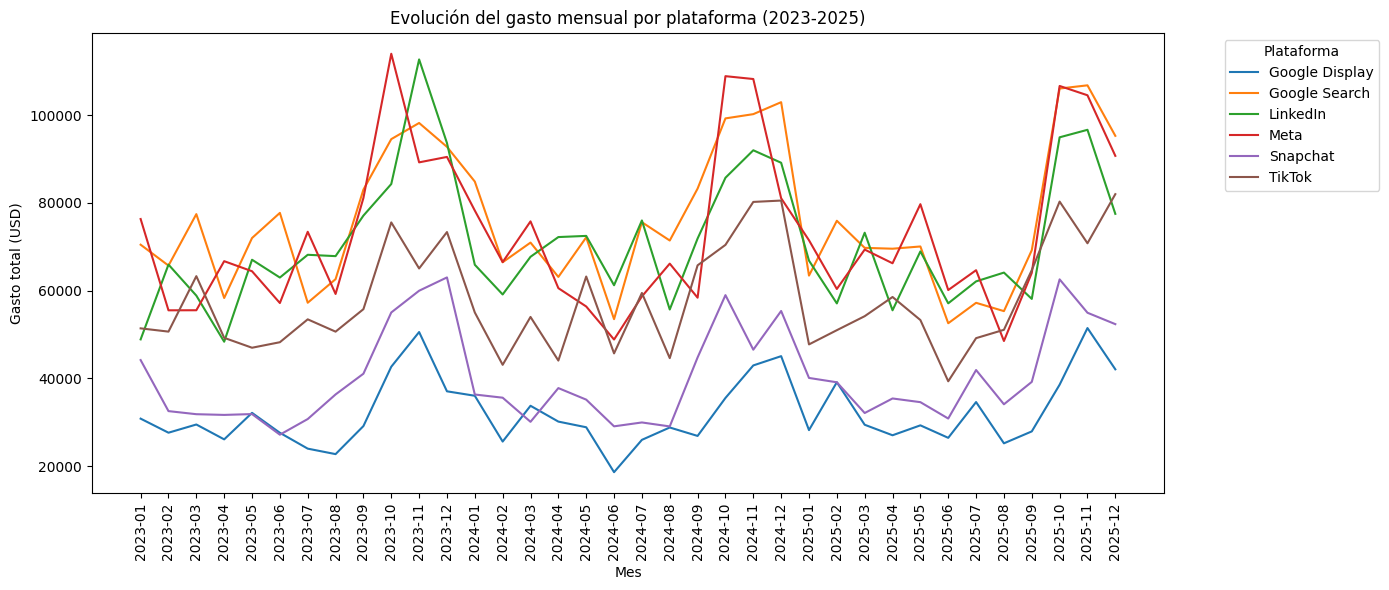

In [16]:
# Creamos una columna de año-mes para agrupar
df['año_mes'] = df['date'].dt.to_period('M')

# Sumamos el gasto total por mes y plataforma
gasto_mensual = df.groupby(['año_mes', 'platform'])['spend'].sum().reset_index()
gasto_mensual['año_mes'] = gasto_mensual['año_mes'].astype(str)

# Graficamos
plt.figure(figsize=(14, 6))
sns.lineplot(data=gasto_mensual, x='año_mes', y='spend', hue='platform')
plt.xlabel('Mes')
plt.ylabel('Gasto total (USD)')
plt.title('Evolución del gasto mensual por plataforma (2023-2025)')
plt.xticks(rotation=90)
plt.legend(title='Plataforma', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

**Interpretación:** El gasto en publicidad muestra un patrón estacional claro
y repetido en los 3 años: se observan picos marcados en octubre-noviembre
(posiblemente asociados a Black Friday / Cyber Monday / fin de año) y en
diciembre-enero, mientras que los meses de mitad de año (junio-julio) muestran
los niveles más bajos de inversión. Meta y Google Search se mantienen
consistentemente como las plataformas con mayor gasto absoluto, mientras que
Google Display registra los niveles más bajos durante todo el período.



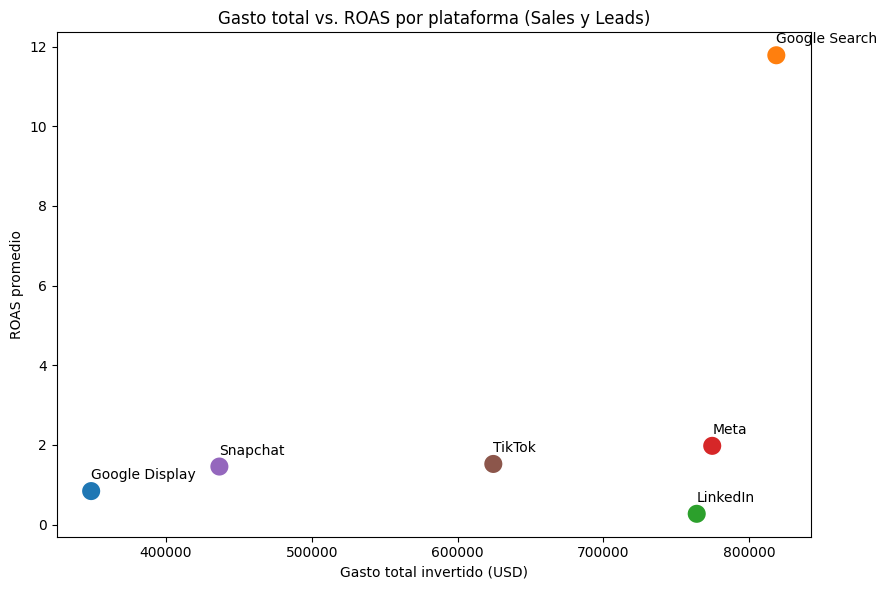

In [17]:
resumen_plataforma = df_conversion.groupby('platform').agg(
    gasto_total=('spend', 'sum'),
    roas_promedio=('roas', 'mean')
).reset_index()

plt.figure(figsize=(9, 6))
sns.scatterplot(data=resumen_plataforma, x='gasto_total', y='roas_promedio',
                 hue='platform', s=200, legend=False)

# Agregamos el nombre de cada plataforma al lado de su puntito
for i, row in resumen_plataforma.iterrows():
    plt.text(row['gasto_total'], row['roas_promedio'] + 0.3, row['platform'])

plt.xlabel('Gasto total invertido (USD)')
plt.ylabel('ROAS promedio')
plt.title('Gasto total vs. ROAS por plataforma (Sales y Leads)')
plt.tight_layout()
plt.show()

**Interpretación:** Google Search se destaca claramente en la esquina superior
derecha: es la plataforma con mayor inversión total y, al mismo tiempo, el
ROAS más alto/una combinación ideal ("gasta mucho y rinde mucho"). Meta,
pese a tener un gasto total similar a Google Search, obtiene un ROAS mucho
menor, lo que indica menor eficiencia relativa. LinkedIn muestra el peor
desempeño: gasto considerable con el ROAS más bajo del grupo, sugiriendo que
no es una plataforma recomendable para objetivos de conversión directa en
este contexto. Google Display y Snapchat invierten menos, con rendimiento
moderado-bajo.


In [18]:
from google.colab import files
files.download('digital_marketing_clean.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>